# 42. One-dimensional discriminant PDFs

**Objectives:**
- Build the four basic finite-interval 1D PDFs: `Gaussian1D`, `Exponential1D`, `Histogram1D`, `BreitWigner1D`.
- Plot each one and numerically confirm it integrates to 1 over its declared `[low, high]` interval.

These PDFs describe discriminating variables beyond the Dalitz plot itself (a reconstructed
parent mass, a BDT response, a PID variable, ...); see `docs/discriminants_and_constraints.md`.
Run cells in order in a fresh kernel. This notebook uses only generated data.


In [1]:
from dalitzplotfitter import enable_x64
enable_x64()  # Must precede numerical work: amplitudes and PDFs use complex128/float64.

import numpy as np
import matplotlib.pyplot as plt

from dalitzplotfitter import BreitWigner1D, Exponential1D, Gaussian1D, Histogram1D


## 1. `Gaussian1D`

A truncated, renormalized Gaussian on `[low, high]`: the raw Gaussian density is divided by the
probability it would place inside the interval, so the *truncated* PDF integrates to exactly 1,
not the full-line Gaussian.


Gaussian1D integral over [low, high] = 1.000000


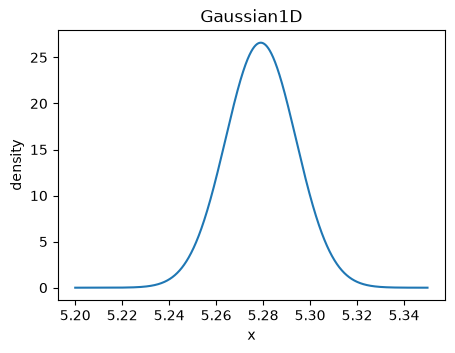

In [2]:
gauss = Gaussian1D(mean=5.279, sigma=0.015, low=5.20, high=5.35)
x_gauss = np.linspace(5.20, 5.35, 2000)
y_gauss = np.asarray(gauss(x_gauss))

integral_gauss = np.trapezoid(y_gauss, x_gauss)
print(f"Gaussian1D integral over [low, high] = {integral_gauss:.6f}")
assert abs(integral_gauss - 1.0) < 1e-4

plt.figure(figsize=(5, 3.5))
plt.plot(x_gauss, y_gauss)
plt.xlabel("x")
plt.ylabel("density")
plt.title("Gaussian1D")
plt.show()


## 2. `Exponential1D`

`exp(slope * x)` normalized on `[low, high]`. A near-zero `slope` is handled as a flat PDF
(`1 / (high - low)`) to avoid a `0/0` division in the normalization.


Exponential1D integral over [low, high] = 1.000000


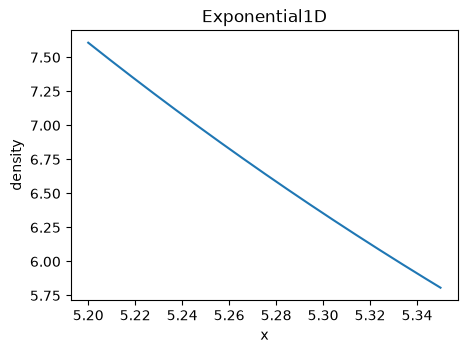

In [3]:
expo = Exponential1D(slope=-1.8, low=5.20, high=5.35)
x_expo = np.linspace(5.20, 5.35, 2000)
y_expo = np.asarray(expo(x_expo))

integral_expo = np.trapezoid(y_expo, x_expo)
print(f"Exponential1D integral over [low, high] = {integral_expo:.6f}")
assert abs(integral_expo - 1.0) < 1e-4

plt.figure(figsize=(5, 3.5))
plt.plot(x_expo, y_expo)
plt.xlabel("x")
plt.ylabel("density")
plt.title("Exponential1D")
plt.show()


## 3. `Histogram1D`

A piecewise-constant PDF from `edges`/`values`; `len(edges) == len(values) + 1`. The constructor
rescales `values` by `sum(widths * values)` so the result is already normalized -- the
`__call__` method returns that rescaled `values` array directly on each bin.


Histogram1D integral over [low, high] = 1.000058


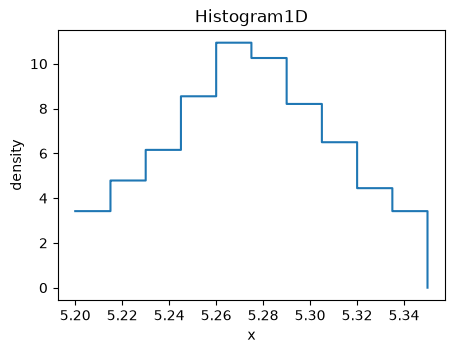

In [4]:
edges = np.linspace(5.20, 5.35, 11)
raw_values = np.array([1.0, 1.4, 1.8, 2.5, 3.2, 3.0, 2.4, 1.9, 1.3, 1.0])
hist = Histogram1D(edges=edges, values=raw_values)

x_hist = np.linspace(5.20, 5.35, 4000)
y_hist = np.asarray(hist(x_hist))
integral_hist = np.trapezoid(y_hist, x_hist)
print(f"Histogram1D integral over [low, high] = {integral_hist:.6f}")
assert abs(integral_hist - 1.0) < 1e-3

plt.figure(figsize=(5, 3.5))
plt.step(x_hist, y_hist, where="post")
plt.xlabel("x")
plt.ylabel("density")
plt.title("Histogram1D")
plt.show()


## 4. `BreitWigner1D`

A constant-width (non-relativistic) Breit-Wigner normalized on a finite mass interval via the
analytic `arctan` antiderivative of the Lorentzian -- unrelated to the two-dimensional Dalitz
amplitude lineshapes in `dynamics/lineshape/`, this is a plain 1D discriminant PDF.


BreitWigner1D integral over [low, high] = 1.000000


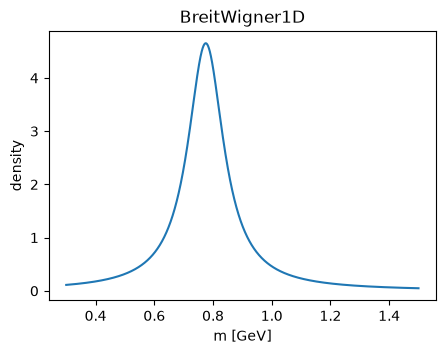

In [5]:
bw = BreitWigner1D(mean=0.7753, width=0.1491, low=0.3, high=1.5)
x_bw = np.linspace(0.3, 1.5, 4000)
y_bw = np.asarray(bw(x_bw))

integral_bw = np.trapezoid(y_bw, x_bw)
print(f"BreitWigner1D integral over [low, high] = {integral_bw:.6f}")
assert abs(integral_bw - 1.0) < 1e-4

plt.figure(figsize=(5, 3.5))
plt.plot(x_bw, y_bw)
plt.xlabel("m [GeV]")
plt.ylabel("density")
plt.title("BreitWigner1D")
plt.show()


## Summary and exercises

1. All four PDFs are `dataclass`es that accept ordinary floats or fit `Parameter` objects for
   their shape parameters (`mean`, `sigma`, `slope`, `width`) -- try passing a `Parameter`
   instead of a float and confirm the call still works with `parameters=None`.
2. Shrink `[low, high]` around one tail of `Gaussian1D` or `BreitWigner1D` and watch the
   renormalization grow the peak density accordingly, since the truncated PDF must still
   integrate to 1 on the shorter interval.
3. Continue with [Factorized densities and constraints](tutorial_43_factorized_density_and_constraints.ipynb),
   which multiplies a Dalitz density by one of these 1D PDFs.

Reference: `docs/discriminants_and_constraints.md`.

Return to [the course guide](TUTORIALS.md).
